# Laboratorio 1 – Gráfico de Visibilidad de Objetos Astronómicos

**De la teoría (Clases 1A y 1B) a la práctica: Unidad 1 – Coordenadas Celestes**

**Laboratorio de Astronomía I – Universidad Andrés Bello**

## Objetivos

Al finalizar este notebook el estudiante será capaz de:

- Aplicar los sistemas de coordenadas Alt-Az y Ecuatorial vistos en la Clase 1A para describir la posición de un objeto en el cielo.
- Usar los conceptos de tiempo sideral local (LST), ángulo horario (HA) y la fórmula de altura vistos en la Clase 1B.
- Representar un observatorio con `EarthLocation` y transformar coordenadas al sistema `AltAz` usando Astropy.
- Incorporar la posición del Sol (crepúsculos) y de la Luna (fase, altura) en la planificación de una noche de observación.
- Construir e interpretar un **gráfico de visibilidad** (altura y masa de aire en función del tiempo) para responder: ¿se puede observar?, ¿cuándo? y ¿por cuánto tiempo?

> **Prerrequisitos:** este notebook asume que ya revisaste el notebook de la Clase 1A (esfera celeste, coordenadas Alt-Az y Ecuatoriales, `SkyCoord`) y los contenidos de la Clase 1B (movimientos de la Tierra, LST, ángulo horario, épocas y marcos de referencia).


# ¿Qué es un gráfico de visibilidad?

Como se vio en la Clase 1B, el **gráfico de visibilidad** es una herramienta indispensable para planificar una noche de observación.

Para un sitio y una noche concretos, muestra cómo cambia la **altura** de un objeto sobre el horizonte (coordenadas Alt-Az) a lo largo del tiempo:

- **Eje horizontal:** tiempo a lo largo de la noche (UT o LST).
- **Eje vertical:** altura $h$ en grados (o, equivalentemente, la masa de aire).
- **La curva:** el objeto sube, culmina al cruzar el meridiano local con $h = 90° - |\varphi - \delta|$, y luego vuelve a bajar.
- **Capas extra (opcionales):** crepúsculos, trayectoria y fase de la Luna, y los límites mecánicos del telescopio.

> **Concepto:** un gráfico de visibilidad no es un capricho estético — es la forma estándar en la que astrónomos profesionales deciden si un objeto es observable, en qué ventana horaria y con qué calidad (masa de aire, cercanía de la Luna).


# Repaso: los ingredientes del cálculo

En la Clase 1A vimos dos sistemas de coordenadas complementarios:

| Sistema | Basado en | Ángulos | ¿Cambia con el tiempo? |
|---|---|---|---|
| Alt-Az (horizontal) | El observador | Azimut ($A$), Altura ($h$) | Sí, todo el tiempo (rotación terrestre) |
| Ecuatorial | La Tierra (eje de rotación) | Ascensión Recta ($\alpha$), Declinación ($\delta$) | No (aprox. fijo, salvo precesión/movimiento propio) |

Los catálogos (SIMBAD, Gaia, etc.) entregan $\alpha,\delta$ en coordenadas **ecuatoriales**, pero para saber si un objeto está sobre el horizonte necesitamos su altura en **Alt-Az**. El puente entre ambos sistemas es exactamente lo que vimos en la Clase 1B.

## La fórmula clave (Clase 1B)

**Ángulo horario:**
$$H = \mathrm{LST} - \alpha$$

**Altura del objeto:**
$$\sin h = \sin\varphi \sin\delta + \cos\varphi \cos\delta \cos H$$

donde $\varphi$ es la latitud del observador, $\delta$ la declinación del objeto y $H$ su ángulo horario.

Los pasos para construir el gráfico, siguiendo la Clase 1B, son:

1. Elegir el sitio ($\varphi, \lambda$, altitud) y la noche a observar.
2. Tomar $\alpha$ y $\delta$ del catálogo, en la época de la observación.
3. Convertir la hora civil a UT, y de ahí a Día Juliano (JD).
4. Calcular el LST para cada instante de la noche.
5. Calcular $H = \mathrm{LST} - \alpha$ y luego $h$ con la fórmula anterior.
6. Repetir cada 10–15 minutos y graficar $h$ en función del tiempo.

En este notebook seguiremos estos mismos pasos, primero "a mano" (como en la pizarra) y luego usando las herramientas que Astropy nos entrega para automatizarlo.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.time import Time
from astropy.coordinates import EarthLocation, SkyCoord, AltAz, get_sun, get_body
import astropy.units as u

plt.rcParams["figure.dpi"] = 100

# Paso 1: El observador → `EarthLocation`

Así como `SkyCoord` describe un punto en el cielo, `EarthLocation` describe un punto en la Tierra: latitud ($\varphi$), longitud ($\lambda$) y altitud, tal como vimos con el sistema GRS80 en la Clase 1B.

Algunos observatorios reales (Clase 1B, tabla de coordenadas):

| Observatorio | Ubicación | Latitud ($\varphi$) | Longitud ($\lambda$) | Altitud |
|---|---|---|---|---|
| Paranal (VLT) | Desierto de Atacama, Chile | −24.6275° | −70.4045° | 2635 m |
| Mauna Kea | Hawái, EE. UU. | +19.8230° | −155.4694° | 4205 m |
| Roque de los Muchachos | La Palma, España | +28.7573° | −17.8850° | 2396 m |
| ALMA | Llano de Chajnantor, Chile | −23.0235° | −67.7539° | 5058 m |
| Real Observatorio de Greenwich | Londres, Reino Unido | +51.4769° | −0.0005° | 46 m |

Trabajaremos con **Paranal (VLT)**, en Chile, como observatorio de referencia.


In [2]:
paranal = EarthLocation(lat=-24.6275*u.deg, lon=-70.4045*u.deg, height=2635*u.m)

print("Latitud: ", paranal.lat)
print("Longitud:", paranal.lon)
print("Altitud: ", paranal.height)

Latitud:  -24d37m39s
Longitud: -70d24m16.2s
Altitud:  2634.9999999996217 m


# Paso 2: El objeto → `SkyCoord`

Usaremos **Betelgeuse**, la misma estrella del ejercicio de la Clase 1A, para poder comparar resultados.

> **Regla de oro (Clase 1B):** unas coordenadas sin época declarada están incompletas. Por defecto `SkyCoord` asume el marco **ICRS** (equivalente en la práctica a J2000.0), que es lo que usaremos aquí.

Como vimos con SIMBAD en la Clase 1A, en un caso real estas coordenadas se obtienen desde un catálogo en vez de escribirlas a mano. La consulta se deja aquí comentada como referencia (requiere conexión a internet).


In [5]:
betelgeuse = SkyCoord('05h55m10.3s +07d24m25s', frame='icrs')
print(betelgeuse)
print("RA  =", betelgeuse.ra)
print("Dec =", betelgeuse.dec)

# --- Alternativa con Astroquery + SIMBAD (igual que en la Clase 1A) ---
# from astroquery.simbad import Simbad
# resultado = Simbad.query_object("Betelgeuse")
# betelgeuse = SkyCoord(ra=resultado["ra"][0], dec=resultado["dec"][0],
#                        unit=(u.deg, u.deg), frame="icrs")

<SkyCoord (ICRS): (ra, dec) in deg
    (88.79291667, 7.40694444)>
RA  = 88d47m34.5s
Dec = 7d24m25s


# Paso 3: El tiempo → `Time`, UT y LST

En la Clase 1B vimos que:

- El **Tiempo Universal (UT)** es la escala de tiempo civil ligada a la rotación terrestre, medida sobre Greenwich. En la práctica, $\mathrm{UT}\approx\mathrm{UTC}$.
- Chile continental usa $\mathrm{UTC}-4$ (o $\mathrm{UTC}-3$ en horario de verano), por lo que **siempre hay que convertir a UT antes de calcular**.
- El **Tiempo Sideral Local (LST)** mide la rotación de la Tierra respecto a las estrellas fijas: indica qué valor de Ascensión Recta está cruzando el meridiano del observador en ese instante.

En Astropy, el objeto `Time` reemplaza el cálculo manual del Día Juliano, y el método `.sidereal_time()` calcula el LST directamente para una longitud dada.


In [6]:
# Medianoche en Paranal, 15 de diciembre de 2025 (hora civil Chile, verano: UTC-3)
# 00:00 hora local de verano == 03:00 UT
medianoche_civil = "2025-12-15 00:00:00 (hora local, UTC-3)"
medianoche_ut = Time("2025-12-15 03:00:00")  # ya convertida a UT

print("Medianoche civil:", medianoche_civil)
print("Medianoche en UT:", medianoche_ut.iso)
print("Día Juliano (JD):", medianoche_ut.jd)

lst = medianoche_ut.sidereal_time("apparent", longitude=paranal.lon)
print("LST en Paranal:  ", lst)

Medianoche civil: 2025-12-15 00:00:00 (hora local, UTC-3)
Medianoche en UT: 2025-12-15 03:00:00.000
Día Juliano (JD): 2461024.625
LST en Paranal:   3h54m29.99452437s


# Paso 4: Ángulo horario y altura — cálculo manual

Repliquemos, para un solo instante, exactamente el procedimiento de la pizarra (Clase 1B, diapositiva "LST: cálculo paso a paso"):

$$H = \mathrm{LST} - \alpha \qquad\qquad \sin h = \sin\varphi\sin\delta + \cos\varphi\cos\delta\cos H$$


In [7]:
H = (lst - betelgeuse.ra).wrap_at(180*u.deg)  # ángulo horario, entre -180° y 180°
print("Ángulo horario H:", H.to(u.hourangle))

phi = paranal.lat.rad
dec = betelgeuse.dec.rad
Hrad = H.rad

sin_h = np.sin(phi)*np.sin(dec) + np.cos(phi)*np.cos(dec)*np.cos(Hrad)
altura_manual = np.degrees(np.arcsin(sin_h))

print(f"Altura de Betelgeuse (cálculo manual): {altura_manual:.2f}°")

Ángulo horario H: -2h00m40.30547563s
Altura de Betelgeuse (cálculo manual): 46.52°


# Paso 5: Automatizando con `AltAz`

Astropy ofrece el marco de referencia `AltAz`, que hace exactamente el cálculo anterior (y además corrige automáticamente efectos finos como precesión, nutación, aberración y refracción atmosférica que no incluimos a mano). Por eso el resultado puede diferir en unos pocos décimos o grados del cálculo manual simplificado.


In [9]:
marco_altaz = AltAz(obstime=medianoche_ut, location=paranal)
betelgeuse_altaz = betelgeuse.transform_to(marco_altaz)

print(f"Altura (Astropy):  {betelgeuse_altaz.alt:.2f}")
print(f"Azimut (Astropy):  {betelgeuse_altaz.az:.2f}")
print(f"Altura (manual):   {altura_manual:.2f}°")
print(f"Diferencia:        {abs(betelgeuse_altaz.alt.deg - altura_manual):.2f}°")

Altura (Astropy):  46.28 deg
Azimut (Astropy):  46.79 deg
Altura (manual):   46.52°
Diferencia:        0.24°


> **Concepto:** la pequeña diferencia entre el cálculo manual y el de Astropy no es un error — es la diferencia entre un modelo esférico simple (el que usamos en la pizarra) y un modelo que incluye las correcciones astrométricas finas que Astropy aplica por defecto. Para planificación observacional, ambas son perfectamente válidas.


# Paso 6: Repitiendo el cálculo durante toda la noche

Siguiendo el paso 6 de la Clase 1B ("repetir cada 10–15 minutos y graficar"), generamos un arreglo de tiempos que cubre la noche completa y calculamos la altura del objeto en cada instante.


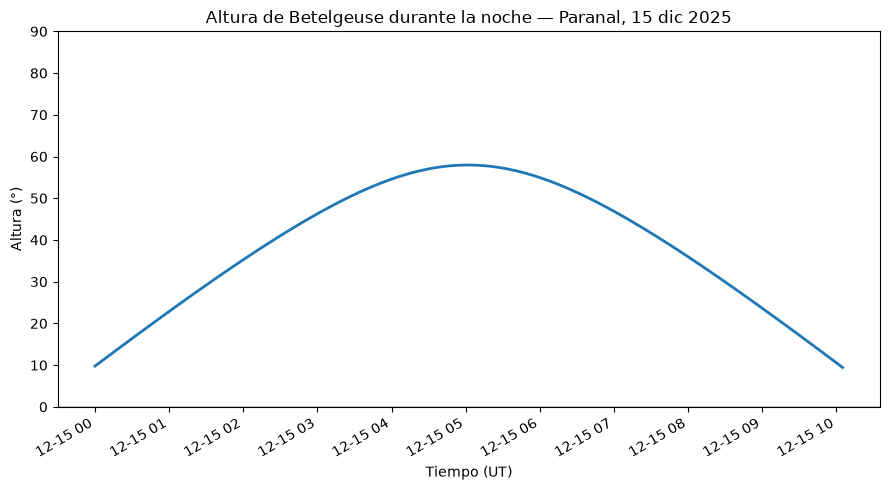

In [10]:
t0 = Time("2025-12-15 00:00:00")  # 00:00 UT del 15 de diciembre de 2025
horas = np.arange(0, 10 + 1/12, 1/12)  # cada 5 minutos, durante 10 horas
tiempos = t0 + horas*u.hour

marco_noche = AltAz(obstime=tiempos, location=paranal)
betelgeuse_noche = betelgeuse.transform_to(marco_noche)

plt.figure(figsize=(9, 5))
plt.plot(tiempos.datetime, betelgeuse_noche.alt.deg, color="tab:blue", lw=2)
plt.axhline(0, color="black", lw=1)
plt.xlabel("Tiempo (UT)")
plt.ylabel("Altura (°)")
plt.ylim(0,90)
plt.title("Altura de Betelgeuse durante la noche — Paranal, 15 dic 2025")
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

# Paso 7: Agregar el Sol — crepúsculos

La "ventana útil" de observación está limitada por la altura del Sol, no por la hora de reloj. Se define habitualmente mediante los crepúsculos:

| Crepúsculo | Altura del Sol |
|---|---|
| Civil | entre 0° y −6° |
| Náutico | entre −6° y −12° |
| Astronómico | entre −12° y −18° |
| Noche astronómica | por debajo de −18° |

Como se vio en la Clase 1B, la noche astronómica (Sol a −18°) es el criterio estándar para definir el inicio y fin de la ventana de observación profesional.

Calculamos la posición del Sol con `get_sun` y la transformamos también al marco `AltAz`.


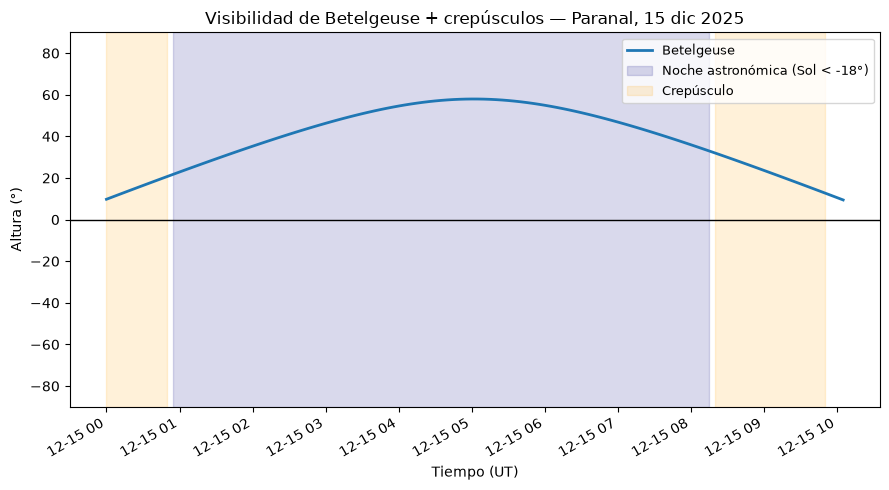

In [11]:
sol_noche = get_sun(tiempos).transform_to(marco_noche)

plt.figure(figsize=(9, 5))
plt.plot(tiempos.datetime, betelgeuse_noche.alt.deg, color="tab:blue", lw=2, label="Betelgeuse")
plt.axhline(0, color="black", lw=1)

plt.fill_between(tiempos.datetime, -90, 90,
                  where=(sol_noche.alt.deg < -18),
                  color="navy", alpha=0.15, label="Noche astronómica (Sol < -18°)")
plt.fill_between(tiempos.datetime, -90, 90,
                  where=(sol_noche.alt.deg >= -18) & (sol_noche.alt.deg < 0),
                  color="orange", alpha=0.15, label="Crepúsculo")

plt.ylim(-90, 90)
plt.xlabel("Tiempo (UT)")
plt.ylabel("Altura (°)")
plt.title("Visibilidad de Betelgeuse + crepúsculos — Paranal, 15 dic 2025")
plt.legend(loc="upper right", fontsize=9)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

# Paso 8: Agregar la Luna — fase y altura

La cercanía y el brillo de la Luna afectan directamente la calidad de una observación (fondo de cielo más brillante). Con `get_body("moon")` obtenemos su posición, y con la separación angular Sol–Luna podemos estimar su **fracción iluminada** (fase), usando la aproximación:

$$k \approx \frac{1 - \cos(\text{elongación})}{2}$$

donde la elongación es la separación angular entre el Sol y la Luna vistos desde la Tierra.


In [12]:
luna_noche = get_body("moon", tiempos, location=paranal).transform_to(marco_noche)

# Fracción iluminada aproximada, evaluada a medianoche
sol_geocentrico = get_sun(medianoche_ut)
luna_geocentrica = get_body("moon", medianoche_ut)
elongacion = sol_geocentrico.separation(luna_geocentrica)
fraccion_iluminada = (1 - np.cos(elongacion.rad)) / 2

print(f"Elongación Sol-Luna:   {elongacion:.1f}")
print(f"Fracción iluminada:    {fraccion_iluminada*100:.0f}%")

Elongación Sol-Luna:   53.9 deg
Fracción iluminada:    21%


# Paso 9: Masa de aire (Airmass)

La **masa de aire** $X$ mide cuánta atmósfera atraviesa la luz de un objeto antes de llegar al telescopio. Cerca del cenit hay menos atmósfera de por medio que cerca del horizonte. La aproximación más simple (válida para $h \gtrsim 20°$) es:

$$X \approx \sec(z) = \frac{1}{\sin h}$$

donde $z = 90° - h$ es la distancia cenital. Se prefiere trabajar con $X < 2$ (equivalente a $h > 30°$) para minimizar la extinción atmosférica y la degradación del *seeing*.

En Astropy, `secz` en el objeto `AltAz` entrega directamente esta cantidad.


In [13]:
def altura_a_airmass(altura_deg):
    altura_deg = np.clip(altura_deg, 1, 90)
    return 1 / np.sin(np.radians(altura_deg))

def airmass_a_altura(X):
    X = np.clip(X, 1, 40)
    return np.degrees(np.arcsin(1 / X))

print("Masa de aire a 30° de altura:", round(altura_a_airmass(30), 2))
print("Masa de aire a 60° de altura:", round(altura_a_airmass(60), 2))
print("Masa de aire a 90° de altura:", round(altura_a_airmass(90), 2))

Masa de aire a 30° de altura: 2.0
Masa de aire a 60° de altura: 1.15
Masa de aire a 90° de altura: 1.0


# Paso 10: El gráfico de visibilidad completo

Juntamos todo lo anterior — objeto, Sol, Luna, masa de aire y altura mínima recomendada — en un único gráfico de visibilidad, tal como se usa para planificar observaciones reales.


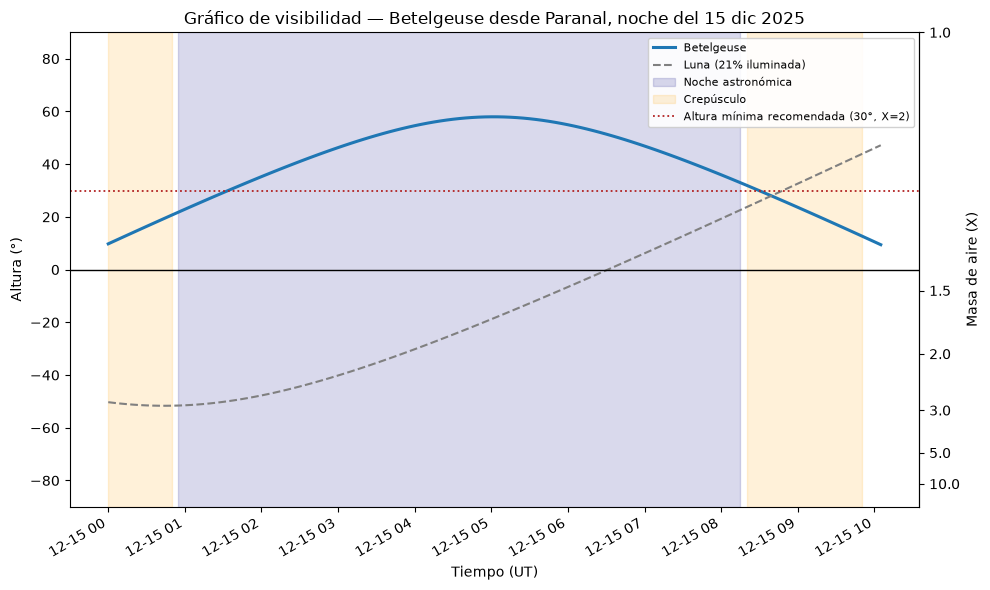

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

# Curva del objeto y de la Luna
ax.plot(tiempos.datetime, betelgeuse_noche.alt.deg, color="tab:blue", lw=2.2, label="Betelgeuse")
ax.plot(tiempos.datetime, luna_noche.alt.deg, color="gray", lw=1.5, ls="--",
        label=f"Luna ({fraccion_iluminada*100:.0f}% iluminada)")

# Crepúsculos
ax.fill_between(tiempos.datetime, -90, 90,
                 where=(sol_noche.alt.deg < -18),
                 color="navy", alpha=0.15, label="Noche astronómica")
ax.fill_between(tiempos.datetime, -90, 90,
                 where=(sol_noche.alt.deg >= -18) & (sol_noche.alt.deg < 0),
                 color="orange", alpha=0.15, label="Crepúsculo")

# Altura mínima recomendada (masa de aire = 2)
ax.axhline(30, color="firebrick", ls=":", lw=1.3, label="Altura mínima recomendada (30°, X=2)")
ax.axhline(0, color="black", lw=1)

ax.set_ylim(-90, 90)
ax.set_xlabel("Tiempo (UT)")
ax.set_ylabel("Altura (°)")
ax.set_title("Gráfico de visibilidad — Betelgeuse desde Paranal, noche del 15 dic 2025")
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)

# Eje secundario derecho: la misma altura, expresada como masa de aire
eje_airmass = ax.secondary_yaxis("right", functions=(altura_a_airmass, airmass_a_altura))
eje_airmass.set_yticks([1, 1.5, 2, 3, 5, 10])
eje_airmass.set_ylabel("Masa de aire (X)")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

> **Nota técnica:** el eje derecho no es un segundo eje independiente — es la **misma** altura expresada en otra unidad (masa de aire), mediante `ax.secondary_yaxis`. Esto es distinto de graficar dos variables independientes en dos escalas distintas (lo cual conviene evitar, porque puede sugerir relaciones que no existen); aquí ambos ejes describen exactamente la misma curva.


# Cómo leer el gráfico (Clase 1B)

- **Ventana útil:** entre el crepúsculo astronómico vespertino y el matutino (Sol a −18°) — la franja azul del gráfico.
- **Altura mínima:** conviene trabajar con $h > 30°$ ($X < 2$); bajo unos 20° la extinción atmosférica y el *seeing* degradan fuertemente la observación.
- **La Luna:** importan tanto su fase (fracción iluminada) como su separación angular respecto al objeto; cerca de Luna llena el fondo de cielo sube varias magnitudes.
- **El telescopio:** cada instrumento tiene además límites propios de azimut, una zona de exclusión cenital y una declinación máxima alcanzable desde el sitio — información que se agrega según el instrumento real que se vaya a usar.

Con esto podemos responder las tres preguntas clave de toda planificación observacional:

1. **¿Se puede observar?** Sí, si en algún momento la curva supera la altura mínima dentro de la ventana de noche astronómica.
2. **¿Cuándo?** En el rango de tiempo donde la curva azul está sobre la línea de 30° y dentro de la franja de noche astronómica.
3. **¿Por cuánto tiempo?** El ancho de ese intervalo — se puede calcular directamente a partir del arreglo `tiempos`.


In [15]:
observable = (betelgeuse_noche.alt.deg > 30) & (sol_noche.alt.deg < -18)
duracion_horas = observable.sum() * (horas[1] - horas[0])

if observable.any():
    inicio = tiempos[observable][0]
    fin = tiempos[observable][-1]
    print(f"Ventana observable (h > 30°, noche astronómica): {inicio.iso} a {fin.iso} UT")
    print(f"Duración aproximada: {duracion_horas:.1f} horas")
else:
    print("Betelgeuse no cumple los criterios de observabilidad esta noche.")

Ventana observable (h > 30°, noche astronómica): 2025-12-15 01:35:00.000 a 2025-12-15 08:15:00.000 UT
Duración aproximada: 6.8 horas


# Buenas prácticas

1. **Trabaja siempre en UT.** Convierte la hora civil antes de cualquier cálculo (Clase 1B): en Chile continental, $\mathrm{UT} = \mathrm{hora\ local} + 4$ (o $+3$ en horario de verano).
2. **Declara siempre la época y el sistema de referencia** de tus coordenadas (regla de oro de la Clase 1B). `SkyCoord` sin especificar `frame` asume ICRS.
3. **Verifica que el LST y las coordenadas del catálogo estén en el mismo sistema** antes de calcular el ángulo horario.
4. **No te fíes solo de la altura:** revisa también el crepúsculo, la fase lunar y los límites del telescopio antes de dar por observable un objeto.
5. **Automatiza, pero entiende el cálculo manual.** Astropy hace todo esto por ti, pero saber replicarlo "a mano" (Pasos 3 y 4) es lo que te permite detectar errores cuando el resultado automático no tiene sentido.


# (Extra) Cheat codes

Hay una forma fácil de hacer crear estos graficos sin hacerlo de manera manual. eg: `astroplan`

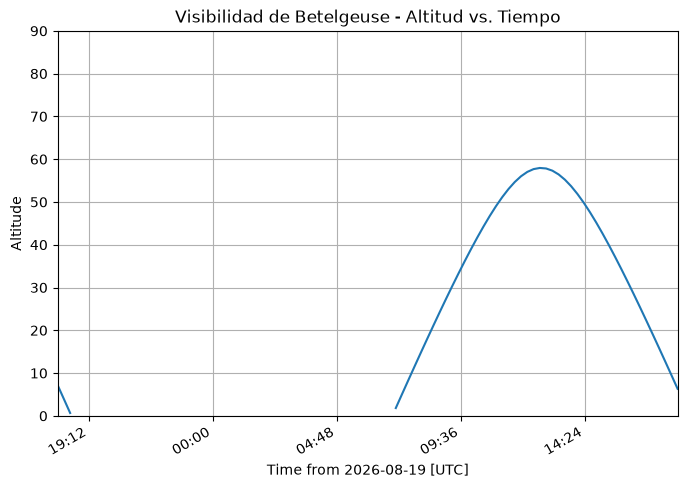

In [17]:
!pip install astroplan

import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from astropy.coordinates import EarthLocation
from astropy.time import Time
from astroplan import Observer, FixedTarget
from astroplan.plots import plot_altitude

# --- PARCHE DE COMPATIBILIDAD MATPLOTLIB ---
plt.Axes.plot_date = lambda self, x, y, *args, **kwargs: self.plot(x, y, *args, **kwargs)
# --------------------------------------------

# 1. Ubicación y Objetivo
location = EarthLocation(lat= -24.6275 * u.deg, lon=-70.4045 * u.deg, height=2635 * u.m)
observer = Observer(location=location, name="Paranal", timezone="UTC")
target = FixedTarget.from_name("Betelgeuse")

# 2. Ventana de tiempo
time = Time("2026-08-20 06:00:00")
time_grid = time + np.linspace(-12, 12, 100) * u.hour

# 3. Gráfico
fig, ax = plt.subplots(figsize=(8, 5))
plot_altitude(target, observer, time_grid, ax=ax)

plt.title("Visibilidad de Betelgeuse - Altitud vs. Tiempo")
plt.grid(True)
plt.show()

# Ejercicio

Elige **un objeto distinto** (puedes buscarlo en SIMBAD, como en la Clase 1A) y **un observatorio distinto** de la tabla del Paso 1 (Mauna Kea, Roque de los Muchachos, ALMA o Greenwich), y construye su gráfico de visibilidad completo para una noche a elección.

1. Define el `EarthLocation` del observatorio elegido.
2. Define el `SkyCoord` del objeto elegido (con su época/frame).
3. Elige una noche y arma el arreglo de tiempos (convierte la hora civil a UT).

**Desafío:** compara la duración de la ventana observable para el mismo objeto visto desde dos observatorios distintos. ¿A qué se debe la diferencia?

## Preguntas de reflexión


1. Si un objeto tiene $\delta$ muy cercano a la latitud del observatorio ($\varphi \approx \delta$), ¿qué le ocurre a su altura máxima? ¿Qué significa esto en la práctica?
2. ¿Por qué es importante usar el criterio de "noche astronómica" ($\mathrm{Sol} < -18°$) y no simplemente "de noche"?
